# Yeast localization CNN

**Task:** 64×64 yeast cell, 2 channels (GFP + RFP) → 19 localization classes.

| # | Part | What |
|---|---|---|
| 0 | Data | download hdf5, plot a few cells |
| 1 | Batches | `x (B,64,64,2)`, `y (B,)` — numpy/JAX, no model |
| 2 | Model | tiny CNN from scratch (Flax/JAX) |
| 3 | Train | loss, one step, then a real loop + val acc |
| 4 | Look | confusion matrix, a few mistakes |
| 5 | Later | same task, pretrained ResNet (PyTorch) |



# Part 0

Get the data images and sanity visualise


In [11]:

from pathlib import Path
import urllib.request
import zipfile

URL = "http://spidey.ccbr.utoronto.ca/~okraus/DeepLoc_full_datasets.zip"
DATA = Path("data")
ZIP = DATA / "DeepLoc_full_datasets.zip"

DATA.mkdir(exist_ok=True)
if not ZIP.exists():
    print("downloading…")
    urllib.request.urlretrieve(URL, ZIP)

# skip unzip if we already extracted something besides the zip
if not any(p.is_dir() for p in DATA.iterdir()):
    print("unzipping…")
    with zipfile.ZipFile(ZIP) as z:
        z.extractall(DATA)


print("done:", list(DATA.iterdir()))
# done: [PosixPath('data/DeepLoc_full_datasets.zip'), PosixPath('data/datasets')]

done: [PosixPath('data/DeepLoc_full_datasets.zip'), PosixPath('data/datasets')]


In [12]:
# inspect the data. 
for p in sorted(Path("data/datasets").iterdir()):
    print(p.name, p.stat().st_size)

# e.g. Chong_train_set.hdf5 773310718
# looks like hdf5 format


Chong_test_set.hdf5 159613644
Chong_train_set.hdf5 773310718
Chong_valid_set.hdf5 158730169
README.TXT 740
Schuldiner_test_set.hdf5 47529863
Schuldiner_train_set.hdf5 424425113
wt2017_test_set.hdf5 179924832
wt2017_train_set.hdf5 1608341400


In [13]:
import h5py
# hdf5 is bit more legacy than modern Zarr format
# stores in one single large file

# print((DATA / "datasets" / "README.TXT").read_text())

train = DATA / "datasets" / "Chong_train_set.hdf5"
with h5py.File(train, "r") as f:
    print(list(f.keys()))
    for k in list(f.keys())[:8]:
        print(k, f[k].shape, f[k].dtype)

['Index1', 'Info1', 'data1', 'label_names']
Index1 (21882, 19) int8
Info1 (21882, 317) float64
data1 (21882, 8192) float32
label_names (21882,) |S16


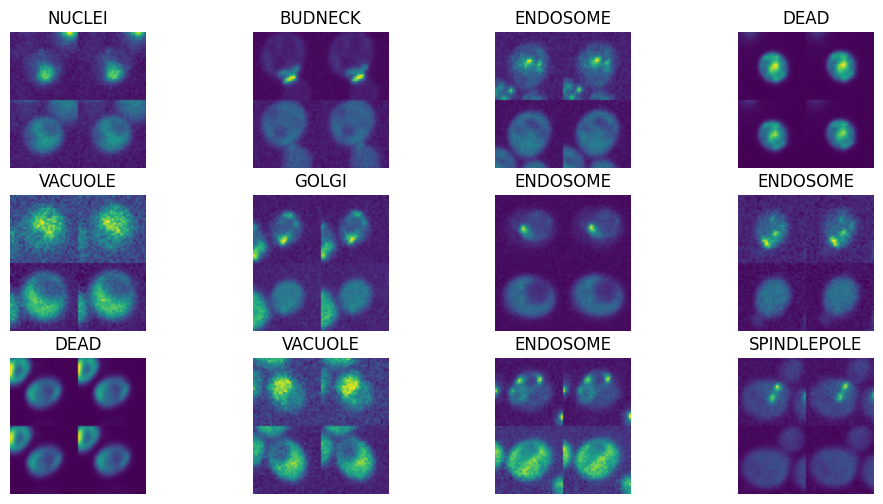

In [14]:
import matplotlib.pyplot as plt

# file was closed by the `with` in the previous cell — reopen it
with h5py.File(train, "r") as f:
    fig, axes = plt.subplots(3, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.ravel()):
        img = f["data1"][i].reshape(64, 64, 2)  # 8192 = 64*64*2
        name = f["label_names"][i].decode()
        ax.imshow(img[:, :, 0])  # channel 0 = GFP; imshow wants 2D
        ax.set_title(name)
        ax.axis("off")


# Part 1: Prep batches

Recall our data:
['Index1', 'Info1', 'data1', 'label_names']
Index1 (21882, 19) int8 --> y label names, 19 classes one hot encoded
Info1 (21882, 317) float64
data1 (21882, 8192) float32 --> X images
label_names (21882,) |S16

N = cells in a split (e.g. 21882). B = batch size (e.g. 32).
A batch is x (B, 64, 64, 2), y (B,) class integers.

We'll make an iterator on the data, and then transformation functions on that

In [ ]:
from collections.abc import Iterator

import numpy as np

IMG_SIZE = 64
N_CHANNELS = 2
N_CLASSES = 19


def decode_images(flat: np.ndarray) -> np.ndarray:
    """(N, 8192) -> (N, 64, 64, 2)."""
    return flat.reshape(flat.shape[0], IMG_SIZE, IMG_SIZE, N_CHANNELS)

def decode_labels(one_hot: np.ndarray) -> np.ndarray:
    """(N, 19) one-hot -> (N,) class indices."""
    return np.argmax(one_hot, axis=1)


# matplotlib doesn't care about scale per image
# but CNNs require common ranges for brightness
def normalise(images: np.ndarray) -> np.ndarray:
    """Per-image, per-channel standardisation."""
    return images / 255.0

# convenience function
def len_X(path: Path) -> int:
    """Number of cells in a split."""
    with h5py.File(path, "r") as f:
        return f["data1"].shape[0]

# we want to map class indices to class names
# maybe useful for plotting or something later
def class_names(path: Path) -> list[str]:
    """Class index -> name, from label_names + Index1."""
    with h5py.File(path, "r") as f:
        y = decode_labels(f["Index1"][:])
        names = f["label_names"][:]
        return [names[y == k][0].decode() for k in range(N_CLASSES)]
        # decode needed since in hdf5 labels are in S16 raw byte format


# we want to stream batches from disk
def iter_batches(
    path: Path,
    batch_size: int = 32,
    shuffle: bool = True,
    seed: int = 24,
) -> Iterator[tuple[np.ndarray, np.ndarray]]:
    """Stream one epoch off disk. Yields (x, y) with x (B,64,64,2), y (B,)."""
    N = len_X(path)
    indices = np.arange(N)
    if shuffle:
        rng = np.random.RandomState(seed)
        rng.shuffle(indices)
    for i in range(0, N, batch_size): # i = 0, 32, 64, …
        batch_indices = indices[i:i+batch_size]
        x = f["data1"][batch_indices]
        y = f["Index1"][batch_indices]

        yield decode_images(x), decode_labels(y)
